In [1]:
from ROOT import TH1D,TStyle,TCanvas,TFile,gStyle,TLegend

def h1_style(h1, title): #make the plots pretty
    h1.GetXaxis().SetTitle("X")
    h1.GetYaxis().SetTitle("N(X)")
    h1.GetXaxis().SetTitleSize(0.05)
    h1.GetYaxis().SetTitleSize(0.05)
    
    h1.GetXaxis().SetLabelSize(0.04)
    h1.GetYaxis().SetLabelSize(0.04)
    h1.SetTitle(title)
    
    h1.SetMaximum(1.25*h1.GetMaximum())


Integral H1: 1819.9999999999998, Integral H2: 1892.8000000000002

Histogram Bin Contents:

Format: <bin number> <h1 bin content> <h2 bin content> <data bin content>
40.00, 39.00, 27.00, 31.00, 34.00, 29.00, 38.00, 32.00, 32.00, 29.00, 34.00, 21.00, 29.00, 30.00, 33.00, 32.00, 28.00, 28.00, 25.00, 33.00, 25.00, 32.00, 26.00, 26.00, 27.00, 23.00, 23.00, 26.00, 29.00, 23.00, 31.00, 20.00, 31.00, 24.00, 25.00, 22.00, 20.00, 24.00, 17.00, 17.00, 17.00, 28.00, 31.00, 23.00, 26.00, 25.00, 25.00, 18.00, 23.00, 24.00, 26.00, 25.00, 19.00, 14.00, 20.00, 22.00, 13.00, 11.00, 20.00, 17.00, 12.00, 18.00, 17.00, 17.00, 13.00, 11.00, 16.00, 9.00, 7.00, 14.00, 4.00, 8.00, 7.00, 7.00, 8.00, 10.00, 7.00, 4.00, 9.00, 11.00, 6.00, 8.00, 4.00, 8.00, 4.00, 4.00, 3.00, 4.00, 5.00, 6.00, 3.00, 4.00, 2.00, 1.00, 5.00, 1.00, 1.00, 0.00, 0.00, 0.00, 

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Info in <TCanvas::Print>: jpg file myPlot.jpg has been created


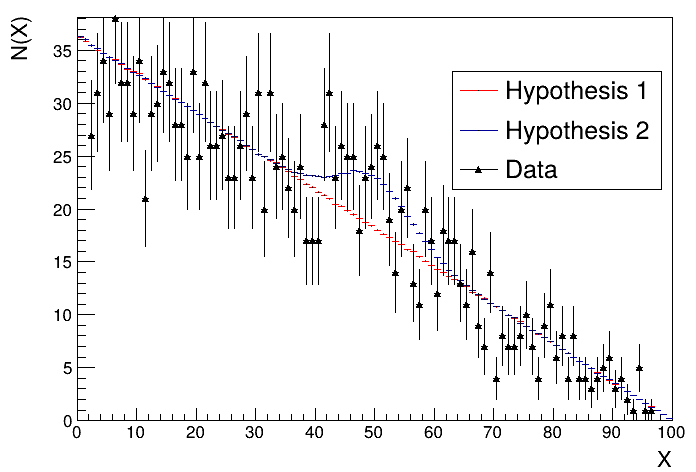

In [10]:
# Tell ROOT to not plot the statistics box on the histograms  
gStyle.SetOptStat(0);

# Open the file with the histograms                                                                                
fin = TFile("hw4_chi2.root","READ")

# Extract histograms     
h1 = fin.Get("Hypothesis 1")
h2 = fin.Get("Hypothesis 2")
data = fin.Get("Data")

# Set the data style with error bars
data.SetLineColor(1);
data.SetMarkerStyle(22);
data.SetMarkerSize(1);

# Adjust the style of the first histogram to be plotted   
h1_style(h1,"")

# Reduce the number of bins from 100 to 25    
rebinFactor = 1;
data.Rebin(rebinFactor);
h1.Rebin(rebinFactor);
h2.Rebin(rebinFactor);

# Normalize hypotheses to the data integral     
h1.Scale(data.Integral())
h2.Scale(data.Integral())

# Report integrals
print("Integral H1: {0}, Integral H2: {1}".format(h1.Integral(),h2.Integral()))

# print out contents of each bin of each histogram     
if False:
    print("\nHistogram Bin Contents:")
    print("\nFormat: <bin number> <h1 bin content> <h2 bin content> <data bin content>")
    for i in range(1,h1.GetNbinsX()+1):
        print("Bin {}: {:.2f} {:.2f} {:.0f}".format(i, h1.GetBinContent(i), h2.GetBinContent(i), data.GetBinContent(i)))

if True:
    print("\nHistogram Bin Contents:")
    print("\nFormat: <bin number> <h1 bin content> <h2 bin content> <data bin content>")
    for i in range(1,h1.GetNbinsX()+1):
        print("{:.2f},".format(data.GetBinContent(i)),end=" ")

# Now make a plot!
leg = TLegend(0.65,0.6, 0.95, 0.85)
leg.AddEntry(h1, "Hypothesis 1")
leg.AddEntry(h2, "Hypothesis 2")
leg.AddEntry(data, "Data")
leg.SetFillColor(0)

c1 = TCanvas("c1","c1")
h1.Draw()
h2.Draw("same")
data.Draw("PEsame")
c1.SetLeftMargin(0.11)
c1.SetBottomMargin(0.11)
c1.SetTopMargin(0.035)
c1.SetRightMargin(0.035)
leg.Draw("same")
c1.Draw()
c1.Print("myPlot.jpg")